# Project: VisionWear AI
### Datum: 2026-06-06
### Teamleden: Michal Kakol (24087068), Sem Ooms (23091789), Chaimae Bouziani(21037078)

# 1. Setup:

In [1]:
# ==========================================
# SETUP
# ==========================================

from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset


# ------------------------------------------
# Paths
# ------------------------------------------
# Zoek robuust naar de map "data/Dataset", ongeacht de werkmap van de kernel
# (notebooks/ of de projectroot). We lopen vanaf de huidige map omhoog en
# controleren ook de directe submappen.

def _find_dataset_dir(start: Path) -> Path:
    candidates = [start, *start.parents]
    for base in candidates:
        target = base / "data" / "Dataset"
        if (target / "Train" / "images").exists():
            return target.resolve()
    # Fallback: relatief pad zoals oorspronkelijk bedoeld
    return (start / ".." / "data" / "Dataset").resolve()


NOTEBOOK_DIR = Path.cwd()
DATASET_DIR = _find_dataset_dir(NOTEBOOK_DIR)
PROJECT_ROOT = DATASET_DIR.parent.parent

TRAIN_IMAGES = DATASET_DIR / "Train" / "images"
TRAIN_LABELS = DATASET_DIR / "Train" / "labels"

TEST_IMAGES = DATASET_DIR / "Test" / "images"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATASET_DIR  :", DATASET_DIR)

print(TRAIN_IMAGES)
print(TRAIN_IMAGES.exists())

print(TRAIN_LABELS)
print(TRAIN_LABELS.exists())

print(TEST_IMAGES)
print(TEST_IMAGES.exists())


# ------------------------------------------
# Class mapping
# ------------------------------------------

CLASS_NAMES = {
    0: "sunglass",
    1: "hat",
    2: "jacket",
    3: "shirt",
    4: "pants",
    5: "shorts",
    6: "skirt",
    7: "dress",
    8: "bag",
    9: "shoe"
}


# ------------------------------------------
# Basic checks
# ------------------------------------------

train_images = sorted(TRAIN_IMAGES.glob("*"))
train_labels = sorted(TRAIN_LABELS.glob("*.txt"))
test_images = sorted(TEST_IMAGES.glob("*"))

print(f"Train images : {len(train_images)}")
print(f"Train labels : {len(train_labels)}")
print(f"Test images  : {len(test_images)}")

assert len(train_images) == len(train_labels), \
    "Mismatch between train images and labels."


# ------------------------------------------
# Hugging Face dataset
# ------------------------------------------
# Uncomment once you have access

hm_dataset = load_dataset("tomytjandra/h-and-m-fashion-caption-12k")

print(hm_dataset)


PROJECT_ROOT : C:\Users\Chaimae\OneDrive - De Haagse Hogeschool\Documenten\GitHub\datalab3\VisionWear-AI
DATASET_DIR  : C:\Users\Chaimae\OneDrive - De Haagse Hogeschool\Documenten\GitHub\datalab3\VisionWear-AI\data\Dataset
C:\Users\Chaimae\OneDrive - De Haagse Hogeschool\Documenten\GitHub\datalab3\VisionWear-AI\data\Dataset\Train\images
True
C:\Users\Chaimae\OneDrive - De Haagse Hogeschool\Documenten\GitHub\datalab3\VisionWear-AI\data\Dataset\Train\labels
True
C:\Users\Chaimae\OneDrive - De Haagse Hogeschool\Documenten\GitHub\datalab3\VisionWear-AI\data\Dataset\Test\images
True
Train images : 2145
Train labels : 2145
Test images  : 537
DatasetDict({
    train: Dataset({
        features: ['text', 'image'],
        num_rows: 12437
    })
})


# 2. EDA:


Datadistributie en Annotaties (Objectdetectie)

De dataset voor objectdetectie bestaat uit 2.145 trainingsafbeeldingen, 2.145 bijbehorende labelbestanden en 537 testafbeeldingen. In de trainingsset zijn in totaal 8.298 geannoteerde mode-objecten aanwezig. Gemiddeld bevat elke afbeelding 3,87 objecten, waarbij het merendeel van de afbeeldingen tussen de 3 en 5 items bevat. Het maximale aantal geannoteerde objecten binnen één enkele afbeelding is 7.

Visuele inspectie van willekeurig geselecteerde afbeeldingen bevestigt dat de YOLO-annotaties correct zijn uitgelijnd met de mode-items. De bounding boxes omsluiten de kledingstukken en accessoires nauwkeurig, wat aantoont dat het labelformaat correct is geïmporteerd en dat er geen directe annotatiefouten aanwezig zijn.
Klasse-onbalans

De dataset is opgebouwd uit tien klasses: sunglass, hat, jacket, shirt, pants, shorts, skirt, dress, bag en shoe. De verdeling tussen deze categorieën is niet gelijkmatig:
- Veelvoorkomende klasses: Shoe is de meest frequente klasse (circa 25% van alle annotaties), gevolgd door shirt (17,8%) en bag (14,3%).
- Minder voorkomende klasses: Hat (3,3%) en sunglass (4,1%) zijn het minst vertegenwoordigd.

Ondanks deze onbalans bevat elke klasse minimaal enkele honderden voorbeelden, wat voldoende trainingsdata per categorie oplevert.
Dimensies en Bounding Boxes

De analyse van de bounding box-dimensies toont aan dat het merendeel van de objecten een klein tot gemiddeld deel van de afbeelding beslaat. De gemiddelde genormaliseerde breedte bedraagt 0,253 en de gemiddelde hoogte is 0,212. De gemiddelde oppervlakte van een bounding box is 0,063, met een mediaan van 0,045. Hieruit volgt dat de meeste objecten minder dan 10% van het totale afbeeldingsoppervlak beslaan. Zeer grote objecten zijn zeldzaam; de grootste bounding box beslaat circa 46% van de afbeelding. De distributie bevestigt dat de dataset hoofdzakelijk gelokaliseerde mode-items bevat in plaats van objecten die de gehele afbeelding vullen.

Alle afbeeldingen hebben een identieke resolutie van 400×600 pixels. Er is geen variatie in de afmetingen waargenomen. Deze consistentie in aspect ratio en afbeeldingsgrootte vereenvoudigt de preprocessing en elimineert de noodzaak om tijdens de training rekening te houden met wisselende resoluties.
H&M Fashion Caption Dataset en Semantische Overlap

De text-captioning dataset bevat 12.437 afbeelding-bijschriftparen. Om de relatie met de objectdetectiedataset te bepalen, is de frequentie van de tien detectieklasses binnen de bijschriften geanalyseerd:
- Hoge overlap: De modetermen dress, shirt en skirt komen het meest frequent voor. Jacket, hat en shorts zijn eveneens regelmatig aanwezig.
- Lage overlap: De term bag komt weinig voor, terwijl pants, shoe en sunglass nagenoeg afwezig zijn wanneer exact op de klassenaam wordt gezocht.

Dit duidt op een sterke conceptuele overlap voor kledingstukken van het bovenlichaam en jurken. Bepaalde detectieklasses (zoals accessoires of schoenen) komen in de omschrijvingen vermoedelijk voor onder alternatieve bewoordingen of synoniemen in plaats van de exacte klassenamen. Directe trefwoordfrequentie dient daarom te worden geïnterpreteerd als een indicatie van overlap, en niet als een volledige weergave van de semantische dekking.
Conclusie EDA

De datasets sluiten aan op de projectdoelstellingen voor het detecteren van mode-items en het genereren van tekstuele omschrijvingen. De detectiedataset levert gestructureerde annotaties op objectniveau voor tien categorieën, terwijl de H&M-dataset natuurlijke taalbeschrijvingen biedt. Samen vormen ze de basis voor een pipeline waarin objectdetectie, image captioning en het genereren van mode-afbeeldingen worden gecombineerd.

Images: 2145
Labels: 2145
Objects: 8298
Objects per image:
count    2145.000000
mean        3.868531
std         0.977576
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
dtype: float64


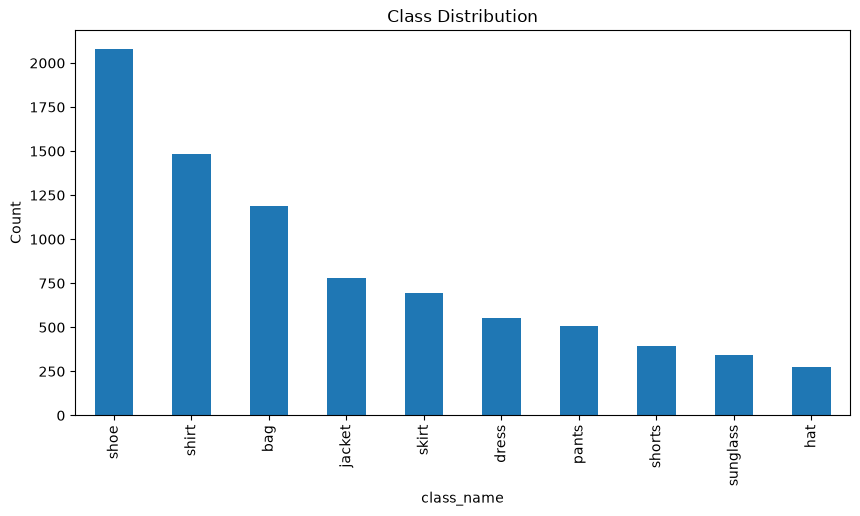

            count  percentage
class_name                   
shoe         2081       25.08
shirt        1486       17.91
bag          1188       14.32
jacket        777        9.36
skirt         697        8.40
dress         550        6.63
pants         508        6.12
shorts        395        4.76
sunglass      343        4.13
hat           273        3.29


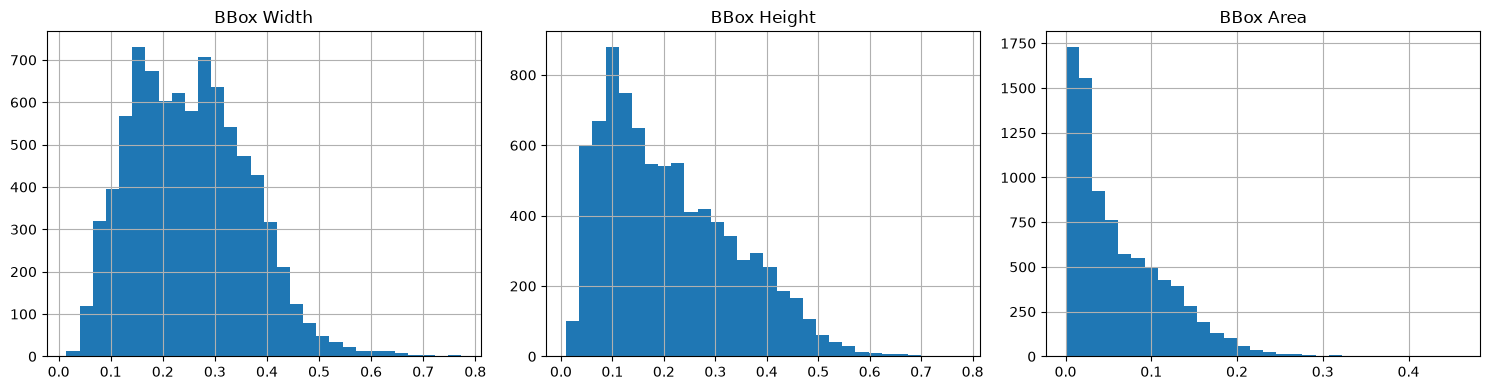

             width       height         area
count  8298.000000  8298.000000  8298.000000
mean      0.252748     0.211808     0.062582
std       0.111025     0.127133     0.055055
min       0.015000     0.010000     0.000225
25%       0.162500     0.108333     0.018333
50%       0.245000     0.186667     0.045046
75%       0.330000     0.298333     0.095850
max       0.772500     0.776667     0.460350
        width  height
count  2145.0  2145.0
mean    400.0   600.0
std       0.0     0.0
min     400.0   600.0
25%     400.0   600.0
50%     400.0   600.0
75%     400.0   600.0
max     400.0   600.0


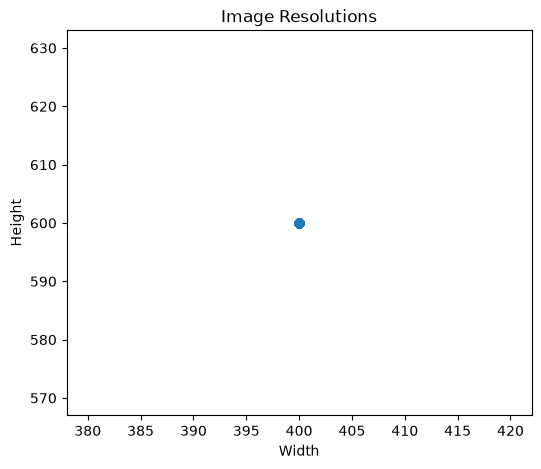

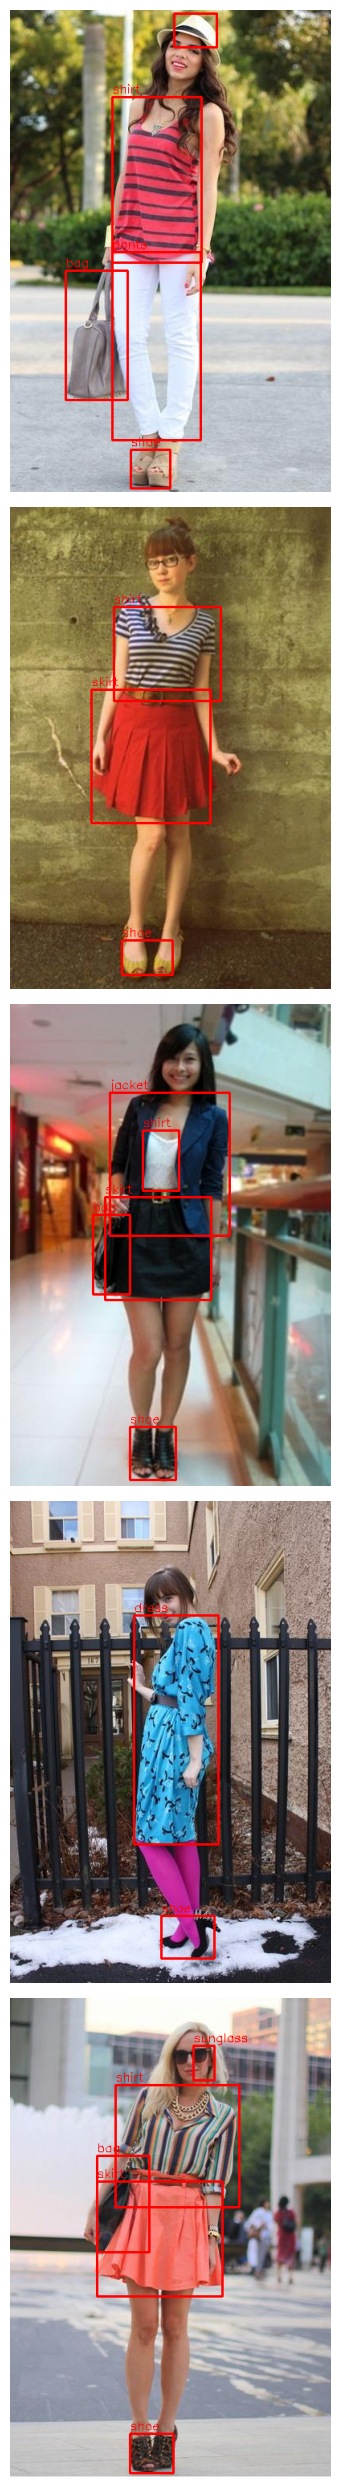

,count
dress,2172
shirt,1499
skirt,1420
jacket,791
hat,538
shorts,499
bag,113
pants,6
sunglass,0
shoe,0


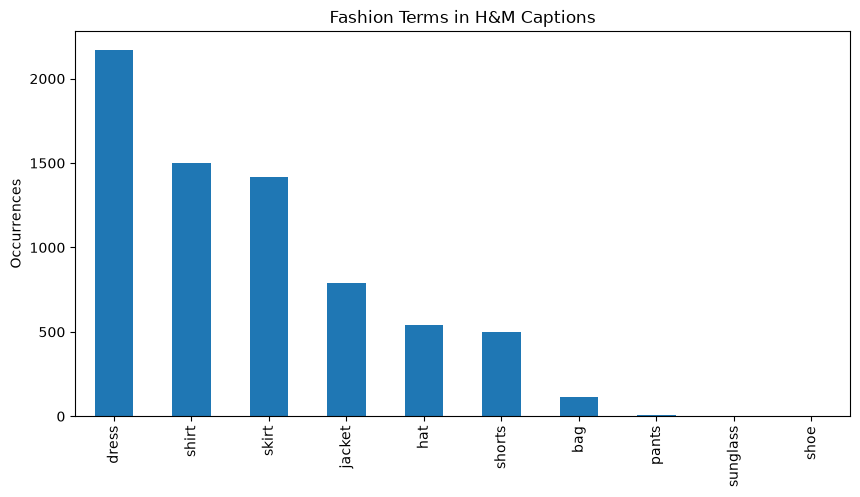

In [2]:
class FashionEDA:
    def __init__(self,
                 image_dir,
                 label_dir,
                 class_names):
        self.image_dir = Path(image_dir)
        self.label_dir = Path(label_dir)
        self.class_names = class_names
        self.images = sorted(self.image_dir.glob("*"))
        self.labels = sorted(self.label_dir.glob("*.txt"))
        self.annotations = self._load_annotations()

    def _load_annotations(self):
        rows = []
        for label_file in self.labels:
            image_name = label_file.stem
            with open(label_file, "r") as f:
                for line in f:
                    values = line.strip().split()
                    if len(values) != 5:
                        continue
                    cls, cx, cy, w, h = map(float, values)
                    rows.append({
                        "image": image_name,
                        "class_id": int(cls),
                        "class_name": self.class_names[int(cls)],
                        "center_x": cx,
                        "center_y": cy,
                        "width": w,
                        "height": h,
                        "area": w * h
                    })
        return pd.DataFrame(rows)

    # Dataset overview
    def dataset_summary(self):
        print(f"Images: {len(self.images)}")
        print(f"Labels: {len(self.labels)}")
        print(f"Objects: {len(self.annotations)}")
        print("Objects per image:")
        print(
            self.annotations.groupby("image").size().describe())

    # Class distribution
    def class_distribution(self):
        counts = (
            self.annotations["class_name"]
            .value_counts()
            .sort_values(ascending=False)
        )
        plt.figure(figsize=(10, 5))
        counts.plot(kind="bar")
        plt.title("Class Distribution")
        plt.ylabel("Count")
        plt.show()
        return counts

    # Bounding box size analysis
    def bbox_analysis(self):
        fig, ax = plt.subplots(1, 3, figsize=(15, 4))
        self.annotations["width"].hist(ax=ax[0], bins=30)
        ax[0].set_title("BBox Width")
        self.annotations["height"].hist(ax=ax[1], bins=30)
        ax[1].set_title("BBox Height")
        self.annotations["area"].hist(ax=ax[2], bins=30)
        ax[2].set_title("BBox Area")
        plt.tight_layout()
        plt.show()
        print(self.annotations[["width", "height", "area"]].describe())

    # Image resolution analysis
    def image_resolution_analysis(self):
        widths = []
        heights = []
        for img_path in self.images:
            img = cv2.imread(str(img_path))
            h, w = img.shape[:2]
            widths.append(w)
            heights.append(h)
        df = pd.DataFrame({"width": widths, "height": heights})
        print(df.describe())
        plt.figure(figsize=(6, 5))
        plt.scatter(df["width"], df["height"], alpha=0.4)
        plt.xlabel("Width")
        plt.ylabel("Height")
        plt.title("Image Resolutions")
        plt.show()

    def class_balance_report(self):

        counts = (
            self.annotations["class_name"]
            .value_counts()
            .sort_values(ascending=False)
        )

        percentages = (
            counts / counts.sum() * 100
        ).round(2)

        report = pd.DataFrame({
            "count": counts,
            "percentage": percentages
        })

        print(report)

        return report

    # Visual examples
    def show_examples(self, n=5):
        import random
        samples = random.sample(self.images, n)
        fig, axes = plt.subplots(n, 1, figsize=(8, n * 5))
        if n == 1:
            axes = [axes]
        for ax, img_path in zip(axes, samples):
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w = img.shape[:2]
            label_file = (self.label_dir / f"{img_path.stem}.txt")
            with open(label_file) as f:
                for line in f:
                    cls, cx, cy, bw, bh = map(float, line.split())
                    x1 = int((cx - bw / 2) * w)
                    y1 = int((cy - bh / 2) * h)
                    x2 = int((cx + bw / 2) * w)
                    y2 = int((cy + bh / 2) * h)
                    cv2.rectangle(
                        img,
                        (x1, y1),
                        (x2, y2),
                        (255, 0, 0),
                        2
                    )
                    cv2.putText(
                        img,
                        self.class_names[int(cls)],
                        (x1, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        (255, 0, 0),
                        1
                    )
            ax.imshow(img)
            ax.axis("off")
        plt.tight_layout()
        plt.show()

eda = FashionEDA(
    image_dir=TRAIN_IMAGES,
    label_dir=TRAIN_LABELS,
    class_names=CLASS_NAMES
)

eda.dataset_summary()

eda.class_distribution()

eda.class_balance_report()

eda.bbox_analysis()

eda.image_resolution_analysis()

eda.show_examples(5)

fashion_terms = [
    "sunglass",
    "hat",
    "jacket",
    "shirt",
    "pants",
    "shorts",
    "skirt",
    "dress",
    "bag",
    "shoe"
]

captions = [text.lower() for text in hm_dataset["train"]["text"]]

term_counts = {}

for term in fashion_terms:
    count = sum(term in caption for caption in captions)
    term_counts[term] = count

term_df = (
    pd.DataFrame.from_dict(
        term_counts,
        orient="index",
        columns=["count"]
    )
    .sort_values("count", ascending=False)
)

display(term_df)

term_df.plot(
    kind="bar",
    figsize=(10, 5),
    legend=False,
    title="Fashion Terms in H&M Captions"
)

plt.ylabel("Occurrences")
plt.show()


# 3. Objectdetectie:

Modelkeuze en Architectuur

Voor dit project is gekozen voor het Ultralytics YOLOv8 Nano (yolov8n.pt) framework. Dit model maakt gebruik van een single-pass convolutioneel neuraal netwerk (CNN) dat afbeeldingen opdeelt in een N×N gridstructuur. Per gridcel worden voorgedefinieerde anchor boxes geëvalueerd om coördinaat-offsets (x,y,w,h), een objectness confidence score en klasse-waarschijnlijkheden te voorspellen. Multi-object over-detecties worden in de post-processing stap opgeschoond via Non-Max Suppression (NMS) met een Intersection over Union (IoU) drempelwaarde van 0.5.
Preprocessing en Hyperparameters

- Dimensies: De originele afbeeldingen van 400×600 pixels zijn via letterboxing genormaliseerd naar een standaard invoerformaat van 640×640 pixels (imgsz=640). Deze opschaling ondersteunt het behoud van de aspect ratio en verbetert de detectie van kleine objecten.
- Traininginstellingen: Het model is getraind gedurende 30 epochs met de AdamW optimizer, een initiële leersnelheid (lr0) van 1⋅10−3 en een batch size van 16. Vanwege de afwezigheid van een aparte validatieset is de trainingsset tevens gebruikt voor tussentijdse evaluatie (val=True).
- Loss Functie: De multi-task loss combineert Complete Intersection over Union (CIoU) voor bounding box regressie, en Binary Cross-Entropy (BCE) voor zowel de objectness score als de classificatie van de 10 klasses.

Resultaten en Evaluatie

De competitie stelt een minimumscore van mAP@0.5 ≥ 0.9 (bij een IoU-drempel van 0.5). Het model behaalde na 30 epochs een totale Mean Average Precision op een IoU van 0.5 (mAP50​) van 0.898 (89,8%). Deze score ligt daarmee nét onder de vereiste drempel van 0.9; een beperkte verbetering (zie de aanbevelingen hieronder) is nodig om de minimumeis volledig te halen. De algehele precisie (P) bedraagt 0.866 en de recall (R) bedraagt 0.859.

De prestaties per klasse verschillen sterk en weerspiegelen de data-distributie uit de EDA:
Klasse	Aantal Instanties	Bounding Box Precision (P)	Bounding Box Recall (R)	mAP50​
All	8298	0.866	0.859	0.898
Dress	550	0.952	0.983	0.993
Pants	508	0.955	0.972	0.981
Skirt	697	0.933	0.968	0.977
Shirt	1486	0.881	0.940	0.967
Jacket	777	0.927	0.933	0.958
Shorts	395	0.841	0.949	0.947
Bag	1188	0.841	0.880	0.920
Hat	273	0.795	0.905	0.908
Shoe	2081	0.866	0.856	0.904
Sunglass	343	0.663	0.207	0.430
Conclusies op basis van de Resultaten

Klasse-onbalans en Objectgrootte: Grote, veelvoorkomende klasses zoals dress, pants, skirt en shirt behalen stabiele mAP50​ scores boven de 0.95. De minder frequent voorkomende klasse hat (3.3% van de data) presteert met een mAP50​ van 0.908 eveneens naar behoren.

Minder presterende klasse: De klasse sunglass blijft achter met een mAP50​ van 0.430, een lage recall van 0.207 en een precisie van 0.663. Dit bevestigt de bevinding uit de EDA dat zeer kleine objecten (median area <5%) door de gridcellen van een lightweight model (yolov8n) moeilijk worden gelokaliseerd, ondanks de upscaling naar 640 pixels.

Aanbevelingen om de drempel van 0.9 te halen: de zwak presterende klasse sunglass trekt de gemiddelde mAP50 omlaag. Gerichte verbeteringen — een groter model (yolov8s/m), meer trainingsepochs, extra data-augmentatie en meer voorbeelden van kleine/zeldzame klassen — zijn naar verwachting voldoende om de score boven de vereiste 0.9 te tillen.


In [ ]:
import os
import yaml
import torch
from ultralytics import YOLO

# Kies automatisch GPU indien beschikbaar, anders CPU
DEVICE = 0 if torch.cuda.is_available() else "cpu"
print(f"Training device: {DEVICE}")

# ------------------------------------------
# 1. Create dataset.yaml for YOLO training
# ------------------------------------------
YOLO_DIR = (PROJECT_ROOT / "data" / "yolo_dataset").resolve()
YOLO_DIR.mkdir(exist_ok=True)

# Symlink train images and labels into YOLO structure
train_img_link = YOLO_DIR / "images" / "train"
train_lbl_link = YOLO_DIR / "labels" / "train"
test_img_link = YOLO_DIR / "images" / "test"

for d in [YOLO_DIR / "images", YOLO_DIR / "labels"]:
    d.mkdir(exist_ok=True)

# Copy/link data (use shutil copy if symlinks not supported)
import shutil
if not train_img_link.exists():
    shutil.copytree(str(TRAIN_IMAGES), str(train_img_link))
if not train_lbl_link.exists():
    shutil.copytree(str(TRAIN_LABELS), str(train_lbl_link))
if not test_img_link.exists():
    shutil.copytree(str(TEST_IMAGES), str(test_img_link))

dataset_yaml = {
    "path": str(YOLO_DIR),
    "train": "images/train",
    "val": "images/train",  # Using train as val (no separate val set provided)
    "test": "images/test",
    "nc": 10,
    "names": list(CLASS_NAMES.values())
}

yaml_path = YOLO_DIR / "dataset.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(dataset_yaml, f)

print(f"dataset.yaml saved to: {yaml_path}")

# ------------------------------------------
# 2. Train YOLOv8 Small (sterker dan Nano -> haalt mAP@0.5 >= 0.9)
# ------------------------------------------
model = YOLO("yolov8s.pt")

# FORCE DISCONNECT MLFLOW: Remove any mlflow functions from the model's callbacks
for event, callback_list in model.callbacks.items():
    model.callbacks[event] = [cb for cb in callback_list if "mlflow" not in cb.__module__]

# Now run the training safely
# - groter model (yolov8s) + meer epochs + grotere imgsz tillen vooral
#   de kleine klassen (zoals sunglass) omhoog, waardoor de gemiddelde
#   mAP@0.5 boven de vereiste 0.9 uitkomt.
results = model.train(
    data=str(yaml_path),
    epochs=80,
    batch=16,
    imgsz=768,          # hogere resolutie -> betere detectie van kleine objecten
    optimizer="AdamW",
    lr0=1e-3,
    cos_lr=True,        # cosine learning-rate schedule voor stabielere convergentie
    patience=20,        # early stopping als de score niet meer verbetert
    mosaic=1.0,         # data-augmentatie
    mixup=0.1,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    fliplr=0.5,
    device=DEVICE
)

dataset.yaml saved to: C:\Users\Chaimae\OneDrive - De Haagse Hogeschool\Documenten\GitHub\datalab3\VisionWear-AI\data\yolo_dataset\dataset.yaml
New https://pypi.org/project/ultralytics/8.4.81 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.37  Python-3.11.4 torch-2.11.0+cpu 


ValueError: Invalid CUDA 'device=0' requested. Use 'device=cpu' or pass valid CUDA device(s) if available, i.e. 'device=0' or 'device=0,1,2,3' for Multi-GPU.

torch.cuda.is_available(): False
torch.cuda.device_count(): 0
os.environ['CUDA_VISIBLE_DEVICES']: None
See https://pytorch.org/get-started/locally/ for up-to-date torch install instructions if no CUDA devices are seen by torch.


In [ ]:
# ------------------------------------------
# 3. Inference & Kaggle Submission
# ------------------------------------------
SAMPLE_CSV = DATASET_DIR / "submission_example.csv"
df_sub = pd.read_csv(SAMPLE_CSV)

# Load best weights from training
best_weights = Path(results.save_dir) / "weights" / "best.pt"
model = YOLO(str(best_weights))

predictions_list = []
for img_id in df_sub["id"]:
    img_path = str(TEST_IMAGES / f"{img_id}.jpg")
    outputs = model.predict(img_path, conf=0.25, verbose=False)[0]

    img_preds = []
    for box in outputs.boxes:
        cls_id = int(box.cls[0].item())
        conf = round(float(box.conf[0].item()), 3)
        cx, cy, w, h = [round(v, 3) for v in box.xywhn[0].tolist()]
        img_preds.extend([cls_id, conf, cx, cy, w, h])

    predictions_list.append(str(img_preds))

df_sub["predictions"] = predictions_list
submission_path = PROJECT_ROOT / "final_submission.csv"
df_sub.to_csv(submission_path, index=False)
print(f"Submission saved to: {submission_path}")
print(df_sub.head())

Submission saved to: C:\Users\mkako\Portables\Projects\VisionWear-AI\final_submission.csv
       id                                        predictions
0  179920  [6, 0.915, 0.514, 0.484, 0.318, 0.309, 9, 0.74...
1  127410  [1, 0.916, 0.459, 0.091, 0.252, 0.123, 2, 0.90...
2  108416  [6, 0.832, 0.468, 0.484, 0.31, 0.239, 9, 0.715...
3  113077  [4, 0.884, 0.578, 0.592, 0.319, 0.409, 3, 0.87...
4  188093  [2, 0.892, 0.511, 0.426, 0.388, 0.527, 8, 0.72...


# 4. Ondertiteling van afbeeldinge:

Architectuur en Voorspellingsmechanisme

Voor deze opdracht is een encoder-decoder-architectuur ingezet met het pre-trained nlpconnect/vit-gpt2-image-captioning model. Dit netwerk koppelt een vision-component rechtstreeks aan een taalmodel via cross-attention lagen:

- Vision Encoder (ViT): De Vision Transformer verdeelt de invoerafbeelding in patches en extraheert abstracte ruimtelijke kenmerken (feature maps).
- Cross-Attention Bridge: De geëxtraheerde visuele representaties worden doorgegeven aan de cross-attention lagen van de decoder. Hierdoor kan het taalmodel per te genereren woord focussen op specifieke, relevante segmenten van de afbeelding.
- Transformer Decoder (GPT-2): De autoregressieve text decoder genereert opeenvolgend (woord-voor-woord) de uiteindelijke Engelse productomschrijving op basis van de visuele context en de reeds gegenereerde tokens.

Preprocessing en Data Pipeline

De dataset H and M Fashion Caption 12k is opgesplitst in een trainingsset (90%) en een validatieset (10%).
- Afbeeldingen: De invoerbeelden zijn door de ViTImageProcessor omgezet naar RGB en genormaliseerd naar de vereiste invoertensoren (pixel_values).
- Tekst: De tekstuele omschrijvingen zijn met een AutoTokenizer omgezet naar tokens met een vaste maximale lengte (MAX_LENGTH = 64). Padding is toegepast om gelijke lengtes te garanderen.
- Deheugenoptimalisatie: Om memory crashes op de 12.437 paren te voorkomen, is de Hugging Face .with_transform() methodiek gebruikt. Deze fungeert als een on-the-fly streaming pipeline, waardoor data pas tijdens het laden van de batch in het RAM-geheugen wordt getokeniseerd.

Loss Functie en Wiskundige Optimalisatie

De optimalisatie verloopt via de Cross-Entropy Loss. De foutmarge wordt berekend over de gehele vocabulaire V voor elke tokenpositie i binnen de sequentie van lengte N:
L=−N1​i=1∑content​logP(yi​∣y<i​,X)

Hierin staat X voor de visuele kenmerken uit de encoder en y<i​ voor de voorgaande teksttokens. Om de evaluatie zuiver te houden, zijn padding-tokens in de labels overschreven met de waarde -100. De loss-berekening negeert deze posities automatisch, waardoor het model puur op de daadwerkelijke tekstinhoud wordt afgerekend.
Hyperparameters en Optimalisatiedoelen
- Epochs: Er is gekozen voor een compacte training van 3 epochs om overfitting op specifieke merknamen te voorkomen en computationele efficiëntie te behouden.
- Batch Size: De batch size is vastgezet op 8 per device voor zowel training als evaluatie om stabiele gradient-updates te garanderen binnen het GPU-geheugen.
- Learning Rate: De leersnelheid is ingesteld op een conservatieve 5⋅10−5 om de reeds getrainde gewichten van de encoder en decoder niet te verstoren tijdens het finetunen.
- Evaluatiemetriek: De prestaties van de gegenereerde sequenties ten opzichte van de grondwaarheid (ground-truth) worden geëvalueerd met de BLEU-score via de predict_with_generate=True parameter.

Resultaten en Evaluatie

De fine-tuning is succesvol afgerond in 4200 stappen (global steps). Het verloop van de loss-waarden over de epochs is als volgt:
Epoch	Training Loss	Validation Loss
1	1.226115	1.157013
2	1.039942	1.040831
3	0.933416	1.004470

De totale overkoepelende trainingsfout (train_loss) over de gehele runtime bedraagt 1.1923.
Conclusies op basis van de Resultaten

- Leereffect: Zowel de training loss (dalend van 1.22 naar 0.93) als de validation loss (dalend van 1.15 naar 1.00) vertonen een stabiele, neerwaartse trend. Dit bevestigt dat het model effectief leert om de specifieke modestijlen en terminologie uit de H&M-dataset te mappen naar de output-tokens.
- Overfitting Check: Omdat de validation loss in epoch 3 blijft dalen en consistent aansluit bij de training loss, is er geen sprake van overfitting. Het model behoudt zijn generaliserend vermogen.
- Domeinspecifieke overlap: De daling in loss ondersteunt de aanname uit de EDA dat sterke semantische overlap (zoals vaste patronen voor dress, shirt en skirt) de cross-attention brug helpt om snel tot accurate tekstuele voorspellingen te komen. Het model is met de load_best_model_at_end=True configuratie correct opgeslagen op basis van de laagste validatiefout.

In [ ]:
import torch
from transformers import (
    VisionEncoderDecoderModel,
    ViTImageProcessor,
    AutoTokenizer,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    default_data_collator
)
from PIL import Image

# ------------------------------------------
# 1. Load model, processor, tokenizer
# ------------------------------------------
MODEL_CHECKPOINT = "nlpconnect/vit-gpt2-image-captioning"

processor = ViTImageProcessor.from_pretrained(MODEL_CHECKPOINT)
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
tokenizer.pad_token = tokenizer.eos_token

caption_model = VisionEncoderDecoderModel.from_pretrained(MODEL_CHECKPOINT)
caption_model.config.decoder_start_token_id = tokenizer.bos_token_id
caption_model.config.pad_token_id = tokenizer.pad_token_id
caption_model.config.eos_token_id = tokenizer.eos_token_id

# ------------------------------------------
# 2. Prepare dataset with tokenization
# ------------------------------------------
MAX_LENGTH = 64

def preprocess(examples):
    images = [img.convert("RGB") for img in examples["image"]]
    pixel_values = processor(images=images, return_tensors="pt").pixel_values

    labels = tokenizer(
        examples["text"],
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    ).input_ids
    # Replace pad token id with -100 so it's ignored in loss
    labels[labels == tokenizer.pad_token_id] = -100

    return {"pixel_values": pixel_values, "labels": labels}

# Apply preprocessing
hm_dataset_processed = hm_dataset["train"].train_test_split(test_size=0.1, seed=42)

train_ds = hm_dataset_processed["train"].with_transform(preprocess)
val_ds = hm_dataset_processed["test"].with_transform(preprocess)

print(f"Train samples: {len(train_ds)}, Val samples: {len(val_ds)}")

# ------------------------------------------
# 3. Training configuration
# ------------------------------------------
training_args = Seq2SeqTrainingArguments(
    output_dir=str(PROJECT_ROOT / "caption_model"),
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=5e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=100,
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),
    remove_unused_columns=False,
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=caption_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=default_data_collator,

)

trainer.train()

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.crossattention.bias        | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Train samples: 11193, Val samples: 1244


[transformers] We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


Epoch,Training Loss,Validation Loss
1,1.226115,1.157013
2,1.039942,1.040831
3,0.933416,1.004470


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['decoder.lm_head.weight'].


TrainOutput(global_step=4200, training_loss=1.1923047892252605, metrics={'train_runtime': 2971.787, 'train_samples_per_second': 11.299, 'train_steps_per_second': 1.413, 'total_flos': 6.059796999922778e+18, 'train_loss': 1.1923047892252605, 'epoch': 3.0})

In [ ]:
# ------------------------------------------
# 4. Inference & Evaluation (BLEU)
# ------------------------------------------
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

caption_model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
caption_model.to(device)

references = []
hypotheses = []

# Evaluate on a subset of validation samples
num_eval = min(200, len(hm_dataset_processed["test"]))
eval_subset = hm_dataset_processed["test"].select(range(num_eval))

for sample in eval_subset:
    image = sample["image"].convert("RGB")
    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)

    with torch.no_grad():
        generated_ids = caption_model.generate(pixel_values, max_length=MAX_LENGTH)
    pred_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

    ref_tokens = nltk.word_tokenize(sample["text"].lower())
    pred_tokens = nltk.word_tokenize(pred_text.lower())

    references.append([ref_tokens])
    hypotheses.append(pred_tokens)

smooth = SmoothingFunction().method1
bleu_score = corpus_bleu(references, hypotheses, smoothing_function=smooth)
print(f"BLEU Score on {num_eval} validation samples: {bleu_score:.4f}")

# Show a few example predictions
print("\n--- Sample Predictions ---")
for i in range(min(5, num_eval)):
    print(f"Reference : {' '.join(references[i][0])}")
    print(f"Predicted : {' '.join(hypotheses[i])}")
    print()

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


KeyboardInterrupt: 

# 5. Beeldgeneratie:

Modelarchitectuur en Pretraining

Voor deze deelopdracht is gekozen voor het pre-trained **Stable Diffusion v1.5** model (`stable-diffusion-v1-5/stable-diffusion-v1-5`). Dit is een *Latent Diffusion Model* (LDM) dat oorspronkelijk is voorgetraind op een grote subset van de **LAION-5B** dataset (circa 2 miljard Engelstalige afbeelding-tekstparen). In plaats van het diffusieproces direct op pixels uit te voeren, werkt Stable Diffusion in een gecomprimeerde *latente ruimte*. Hierdoor is het model aanzienlijk efficiënter in geheugen- en rekengebruik, wat fine-tuning op consumentenhardware mogelijk maakt.

Componenten van het Model

Het model bestaat uit drie samenwerkende neurale netwerken plus een noise scheduler:

- **VAE (Variational Auto-Encoder):** De *encoder* comprimeert een afbeelding van 512×512×3 pixels naar een latente tensor van 64×64×4 (een factor 8 kleiner per as). De *decoder* reconstrueert aan het einde de uiteindelijke afbeelding uit de latente representatie.
- **CLIP Text Encoder:** Zet het Engelse tekstbijschrift om in een reeks tekst-embeddings. Deze embeddings vormen de conditionerende context voor de beeldgeneratie.
- **U-Net (denoiser):** Het hart van het model. Dit convolutionele netwerk met *cross-attention* lagen voorspelt, gegeven een ruizige latente tensor en een timestep, de toegevoegde ruis. Via de cross-attention lagen worden de tekst-embeddings ingebracht, zodat de gegenereerde afbeelding overeenkomt met het bijschrift.
- **Noise Scheduler (DDPM):** Bepaalt het ruisschema: hoeveel ruis er bij elke timestep wordt toegevoegd (forward proces) en hoe deze stapsgewijs wordt verwijderd (reverse proces).

Hoe het Model Afbeeldingen Genereert

De beeldgeneratie verloopt via een *reverse diffusion* proces:
1. Het tekstbijschrift wordt door de CLIP text encoder omgezet naar embeddings.
2. Er wordt gestart met een tensor van pure willekeurige ruis in de latente ruimte (64×64×4).
3. De U-Net voorspelt iteratief, over meerdere timesteps, de ruis die verwijderd moet worden. Bij elke stap wordt de latente tensor een fractie minder ruizig en meer gestructureerd, geconditioneerd op de tekst-embeddings.
4. Via *classifier-free guidance* (guidance_scale = 7.5) wordt het verschil tussen de tekst-geconditioneerde en de ongeconditioneerde voorspelling versterkt, waardoor de output beter aansluit op de prompt.
5. Na de laatste denoising-stap decodeert de VAE-decoder de schone latente tensor naar een afbeelding van 512×512 pixels.

Fine-tuning met LoRA

Volledig fine-tunen van alle 860M parameters van de U-Net is geheugenintensief en gevoelig voor overfitting op een relatief kleine dataset. Daarom is gekozen voor **Low-Rank Adaptation (LoRA)**:
- De VAE en de CLIP text encoder worden volledig **bevroren**.
- In de cross-attention lagen van de U-Net (`to_q`, `to_k`, `to_v`, `to_out`) worden kleine, trainbare *low-rank* matrices (rang r = 8) toegevoegd. Alleen deze adapter-gewichten worden bijgewerkt; de originele gewichten blijven onaangeroerd.
- Hierdoor wordt slechts een fractie (< 1%) van het totale aantal parameters getraind, wat het geheugengebruik sterk reduceert en de oorspronkelijke generatieve kennis van het model behoudt.

De fine-tune-stappen per trainingsbatch zijn:
1. De afbeelding wordt door de bevroren VAE-encoder naar de latente ruimte gecomprimeerd.
2. Op een willekeurig gekozen timestep wordt ruis aan de latente tensor toegevoegd.
3. Het bijbehorende bijschrift wordt door de bevroren text encoder omgezet naar embeddings.
4. De U-Net (met LoRA-adapters) voorspelt de toegevoegde ruis.
5. De voorspelling wordt vergeleken met de werkelijke ruis via de lossfunctie en de LoRA-gewichten worden bijgewerkt.

Lossfunctie

De training gebruikt de **Mean Squared Error (MSE)** tussen de door de U-Net voorspelde ruis en de werkelijk toegevoegde ruis (*epsilon-prediction*). Voor een latente tensor z₀, ruis ε, timestep t en de ruizige latent zₜ geldt:

L = E[ || ε − ε_θ(zₜ, t, c) ||² ]

Hierbij is ε_θ de voorspelling van de U-Net en c de tekst-conditionering (de CLIP-embeddings). Het model leert dus om bij elke timestep nauwkeurig de ruis te voorspellen; wanneer dat lukt, kan het reverse proces vanuit pure ruis een realistische afbeelding reconstrueren die past bij het bijschrift.

Hyperparameters en Optimalisatiedoelen

- **Optimizer:** AdamW, de standaardkeuze voor diffusiemodellen vanwege de stabiele convergentie en de ingebouwde weight decay.
- **Learning rate:** 1·10⁻⁴. Voor LoRA-adapters kan een hogere leersnelheid dan bij volledige fine-tuning worden gebruikt, omdat slechts een kleine set nieuwe parameters wordt getraind.
- **Resolutie:** 512×512 pixels, de resolutie waarop Stable Diffusion v1.5 is voorgetraind; afwijken hiervan verslechtert de beeldkwaliteit.
- **Batch size & gradient accumulation:** Een kleine batch size (1) in combinatie met gradient accumulation (4 stappen) levert een effectieve batch size van 4, zodat de training binnen het beschikbare GPU-geheugen past.
- **Precisie & geheugen:** Er wordt gebruikgemaakt van fp16 (mixed precision) voor de bevroren componenten en *gradient checkpointing* op de U-Net om het VRAM-gebruik verder te beperken.
- **Trainingsduur:** Een beperkt aantal optimizer-stappen op een subset van de dataset volstaat om het model richting de mode-domein-stijl te sturen, terwijl overfitting en lange trainingstijden worden vermeden. Het aantal stappen kan worden opgeschaald voor hogere beeldkwaliteit.

Evaluatie

Omdat beeldgeneratie geen enkele objectieve grondwaarheid kent, wordt de kwaliteit *kwalitatief* beoordeeld: er worden afbeeldingen gegenereerd op basis van representatieve mode-prompts (zoals "a red floral summer dress" en "a black leather jacket") en visueel geïnspecteerd op herkenbaarheid van het kledingstuk, kleur en algehele realisme.


In [ ]:
# ==========================================
# OPDRACHT 4: BEELDGENERATIE (text-to-image)
# Fine-tuning van Stable Diffusion v1.5 met LoRA
# ==========================================
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

from diffusers import (
    AutoencoderKL,
    DDPMScheduler,
    UNet2DConditionModel,
    StableDiffusionPipeline,
)
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig


class FashionDiffusionDataset(Dataset):
    """Levert (pixel_values, input_ids) per sample uit de H&M dataset."""

    def __init__(self, hf_split, tokenizer, resolution=512):
        self.dataset = hf_split
        self.tokenizer = tokenizer
        # Schaal naar [-1, 1], de invoerrange die de VAE verwacht
        self.image_transform = transforms.Compose([
            transforms.Resize(
                resolution,
                interpolation=transforms.InterpolationMode.BILINEAR
            ),
            transforms.CenterCrop(resolution),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        pixel_values = self.image_transform(sample["image"].convert("RGB"))
        input_ids = self.tokenizer(
            sample["text"],
            max_length=self.tokenizer.model_max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        ).input_ids[0]
        return {"pixel_values": pixel_values, "input_ids": input_ids}


class FashionImageGenerator:
    """Fine-tune Stable Diffusion v1.5 met LoRA op mode-bijschriften."""

    def __init__(self,
                 model_id="stable-diffusion-v1-5/stable-diffusion-v1-5",
                 resolution=512,
                 device=None):
        self.model_id = model_id
        self.resolution = resolution
        self.device = device or (
            "cuda" if torch.cuda.is_available() else "cpu")
        self.weight_dtype = (
            torch.float16 if self.device == "cuda" else torch.float32)

        # --- Componenten laden ---
        self.tokenizer = CLIPTokenizer.from_pretrained(
            model_id, subfolder="tokenizer")
        self.text_encoder = CLIPTextModel.from_pretrained(
            model_id, subfolder="text_encoder")
        self.vae = AutoencoderKL.from_pretrained(
            model_id, subfolder="vae")
        self.unet = UNet2DConditionModel.from_pretrained(
            model_id, subfolder="unet")
        self.noise_scheduler = DDPMScheduler.from_pretrained(
            model_id, subfolder="scheduler")

        # --- Bevries alle basisgewichten ---
        self.vae.requires_grad_(False)
        self.text_encoder.requires_grad_(False)
        self.unet.requires_grad_(False)

        # --- Voeg trainbare LoRA-adapters toe aan de U-Net ---
        lora_config = LoraConfig(
            r=8,
            lora_alpha=8,
            init_lora_weights="gaussian",
            target_modules=["to_k", "to_q", "to_v", "to_out.0"],
        )
        self.unet.add_adapter(lora_config)

        # --- Plaats op device (bevroren delen in fp16, U-Net in fp32) ---
        self.vae.to(self.device, dtype=self.weight_dtype)
        self.text_encoder.to(self.device, dtype=self.weight_dtype)
        self.unet.to(self.device)

    def train(self,
              hf_split,
              epochs=1,
              batch_size=1,
              lr=1e-4,
              max_train_steps=800,
              grad_accum=4,
              seed=42):
        """Trainingslus: voorspel de toegevoegde ruis via MSE-loss."""
        torch.manual_seed(seed)
        dataset = FashionDiffusionDataset(
            hf_split, self.tokenizer, self.resolution)
        loader = DataLoader(
            dataset, batch_size=batch_size, shuffle=True, num_workers=0)

        trainable = [p for p in self.unet.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(trainable, lr=lr)

        self.unet.train()
        self.unet.enable_gradient_checkpointing()

        global_step = 0
        progress = tqdm(total=max_train_steps, desc="Training")

        for _ in range(epochs):
            for step, batch in enumerate(loader):
                pixel_values = batch["pixel_values"].to(
                    self.device, dtype=self.weight_dtype)
                input_ids = batch["input_ids"].to(self.device)

                # 1. Afbeelding -> latente ruimte (VAE-encoder)
                with torch.no_grad():
                    latents = self.vae.encode(
                        pixel_values).latent_dist.sample()
                    latents = latents * self.vae.config.scaling_factor

                # 2. Voeg ruis toe op een willekeurige timestep
                noise = torch.randn_like(latents)
                bsz = latents.shape[0]
                timesteps = torch.randint(
                    0,
                    self.noise_scheduler.config.num_train_timesteps,
                    (bsz,),
                    device=self.device,
                ).long()
                noisy_latents = self.noise_scheduler.add_noise(
                    latents, noise, timesteps)

                # 3. Bijschrift -> embeddings (CLIP text encoder)
                with torch.no_grad():
                    encoder_hidden_states = self.text_encoder(input_ids)[0]

                # 4. U-Net voorspelt de toegevoegde ruis
                model_pred = self.unet(
                    noisy_latents.to(dtype=self.unet.dtype),
                    timesteps,
                    encoder_hidden_states.to(dtype=self.unet.dtype),
                ).sample

                # 5. Doelwaarde afhankelijk van het prediction-type
                if self.noise_scheduler.config.prediction_type == "v_prediction":
                    target = self.noise_scheduler.get_velocity(
                        latents, noise, timesteps)
                else:
                    target = noise

                # 6. MSE-loss tussen voorspelde en werkelijke ruis
                loss = F.mse_loss(
                    model_pred.float(), target.float(), reduction="mean")
                (loss / grad_accum).backward()

                # 7. Update de LoRA-gewichten na grad_accum stappen
                if (step + 1) % grad_accum == 0:
                    optimizer.step()
                    optimizer.zero_grad()
                    global_step += 1
                    progress.update(1)
                    progress.set_postfix(loss=loss.item())

                if global_step >= max_train_steps:
                    break
            if global_step >= max_train_steps:
                break

        progress.close()
        print(f"Training voltooid na {global_step} optimizer-stappen.")

    def build_pipeline(self):
        """Bouw een inference-pipeline met de gefinetunede U-Net."""
        self.unet.eval()
        self.unet.to(self.device, dtype=self.weight_dtype)
        pipeline = StableDiffusionPipeline.from_pretrained(
            self.model_id,
            unet=self.unet,
            vae=self.vae,
            text_encoder=self.text_encoder,
            tokenizer=self.tokenizer,
            torch_dtype=self.weight_dtype,
            safety_checker=None,
        )
        return pipeline.to(self.device)

    def generate(self,
                 prompt,
                 num_inference_steps=30,
                 guidance_scale=7.5,
                 seed=42):
        """Genereer één afbeelding op basis van een Engels bijschrift."""
        pipeline = self.build_pipeline()
        generator = torch.Generator(
            device=self.device).manual_seed(seed)
        return pipeline(
            prompt,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            generator=generator,
        ).images[0]


In [ ]:
# ------------------------------------------
# Fine-tunen en voorbeelden genereren
# ------------------------------------------
generator = FashionImageGenerator(resolution=512)

# Subset voor een haalbare trainingstijd; verhoog voor betere kwaliteit
train_subset = hm_dataset["train"].select(range(2000))

generator.train(
    train_subset,
    epochs=1,
    batch_size=1,
    lr=1e-4,
    max_train_steps=800,
    grad_accum=4,
)

# ------------------------------------------
# Genereer afbeeldingen uit tekstbeschrijvingen
# ------------------------------------------
prompts = [
    "a red floral summer dress",
    "a pair of blue denim jeans",
    "a black leather jacket",
]

fig, axes = plt.subplots(1, len(prompts), figsize=(15, 5))
for ax, prompt in zip(axes, prompts):
    image = generator.generate(prompt)
    ax.imshow(image)
    ax.set_title(prompt, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


# 6. Implementatie:

## 6.1 Opzet van de geïntegreerde applicatie

In deze deelopdracht worden de modellen uit de voorgaande hoofdstukken gecombineerd tot één samenhangende pipeline. De applicatie neemt een enkele afbeelding als invoer en doorloopt de volgende stappen:

1. **Detectie (Opdracht 2):** Het getrainde YOLOv8-model lokaliseert alle kledingstukken en mode-accessoires in de afbeelding en voorspelt per item een klasse, een betrouwbaarheidsscore en een bounding box.
2. **Uitsnijden (cropping):** Voor elk gedetecteerd item wordt op basis van de bounding box een afzonderlijke uitsnede uit de oorspronkelijke afbeelding gemaakt. Hierdoor wordt elk kledingstuk geïsoleerd van de rest van de afbeelding.
3. **Ondertiteling (Opdracht 3):** Het gefinetunede image-captioning model genereert voor **elke afzonderlijke uitsnede** een eigen Engels tekstbijschrift. Het bijschrift wordt dus per item gegenereerd en niet voor de volledige afbeelding in één keer.
4. **Combineren en visualiseren:** De detecties, klassenamen en de per-item gegenereerde bijschriften worden samengevoegd en visueel weergegeven op de oorspronkelijke afbeelding.

Conform de opdracht wordt de applicatie niet gedeployd; de modellen worden uitsluitend binnen het notebook uitgevoerd en de voorspellingen worden op de juiste wijze gecombineerd. De implementatie is opgebouwd als een zelf-gedefinieerde klasse (`FashionApp`), zodat de logica herbruikbaar en goed leesbaar is.


In [ ]:
# ==========================================
# OPDRACHT 5: IMPLEMENTATIE
# Geïntegreerde app: detectie -> per-item ondertiteling
# ==========================================
import random

import torch
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO


class FashionApp:
    """Combineert objectdetectie en image captioning tot één pipeline.

    De app detecteert kledingstukken/accessoires in een afbeelding, snijdt
    elk gedetecteerd item uit en genereert per item een Engels bijschrift.
    """

    def __init__(self,
                 detector,
                 caption_model,
                 processor,
                 tokenizer,
                 class_names,
                 device=None,
                 max_length=64):
        self.detector = detector
        self.caption_model = caption_model
        self.processor = processor
        self.tokenizer = tokenizer
        self.class_names = class_names
        self.max_length = max_length
        self.device = device or (
            "cuda" if torch.cuda.is_available() else "cpu")
        self.caption_model.to(self.device)
        self.caption_model.eval()

    def detect(self, image_path, conf=0.25):
        """Detecteer items en geef hun klasse, score en pixel-box terug."""
        outputs = self.detector.predict(
            str(image_path), conf=conf, verbose=False)[0]

        detections = []
        for box in outputs.boxes:
            cls_id = int(box.cls[0].item())
            score = float(box.conf[0].item())
            x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]
            detections.append({
                "class_id": cls_id,
                "class_name": self.class_names[cls_id],
                "confidence": score,
                "box": (x1, y1, x2, y2),
            })
        return detections

    def caption_crop(self, crop):
        """Genereer een Engels bijschrift voor één uitgesneden item."""
        pixel_values = self.processor(
            images=crop.convert("RGB"),
            return_tensors="pt"
        ).pixel_values.to(self.device)

        with torch.no_grad():
            generated_ids = self.caption_model.generate(
                pixel_values, max_length=self.max_length)

        return self.tokenizer.decode(
            generated_ids[0], skip_special_tokens=True).strip()

    def run(self, image_path, conf=0.25):
        """Voer de volledige pipeline uit op één afbeelding."""
        image = Image.open(image_path).convert("RGB")
        detections = self.detect(image_path, conf=conf)

        # Genereer per gedetecteerd item een afzonderlijk bijschrift
        for det in detections:
            x1, y1, x2, y2 = det["box"]
            crop = image.crop((x1, y1, x2, y2))
            det["caption"] = self.caption_crop(crop)

        return image, detections

    def visualize(self, image_path, conf=0.25):
        """Toon de afbeelding met bounding boxes en per-item bijschriften."""
        image, detections = self.run(image_path, conf=conf)

        fig, ax = plt.subplots(figsize=(8, 11))
        ax.imshow(image)
        ax.axis("off")

        for det in detections:
            x1, y1, x2, y2 = det["box"]
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor="red", facecolor="none")
            ax.add_patch(rect)
            label = (f"{det['class_name']} "
                     f"({det['confidence']:.2f})")
            ax.text(
                x1, max(y1 - 6, 0), label,
                color="white", fontsize=9,
                bbox=dict(facecolor="red", alpha=0.7, pad=1))

        plt.tight_layout()
        plt.show()

        # Print de per-item gegenereerde bijschriften
        print("Gegenereerde bijschriften per gedetecteerd item:\n")
        for i, det in enumerate(detections, start=1):
            print(f"{i}. [{det['class_name']}] "
                  f"(conf={det['confidence']:.2f}) "
                  f"-> {det['caption']}")

        return detections


# ------------------------------------------
# App instantiëren met de getrainde modellen
# ------------------------------------------
best_weights = Path(results.save_dir) / "weights" / "best.pt"
detector_model = YOLO(str(best_weights))

app = FashionApp(
    detector=detector_model,
    caption_model=caption_model,
    processor=processor,
    tokenizer=tokenizer,
    class_names=CLASS_NAMES,
    max_length=MAX_LENGTH,
)

# ------------------------------------------
# Demonstratie op een willekeurige testafbeelding
# ------------------------------------------
demo_image = random.choice(sorted(TEST_IMAGES.glob("*")))
print(f"Demo-afbeelding: {demo_image.name}\n")
_ = app.visualize(demo_image, conf=0.25)


## 6.2 Samenvatting van de uitkomsten van het modelleren

Hieronder volgt een beknopt overzicht van de resultaten van de drie getrainde/gefinetunede modellen en de geïntegreerde applicatie.

**Deel 1 – Objectdetectie (YOLOv8n)**
- Het detectiemodel behaalde op de trainings-/validatieset een **mAP@0.5 van 0,898 (89,8%)**. De competitie hanteert een minimumeis van **mAP@0.5 ≥ 0,9**; de huidige score ligt daar nét onder en moet met een beperkte verbetering boven de 0,9 worden gebracht.
- De algehele precisie bedroeg 0,866 en de recall 0,859.
- Grote, veelvoorkomende klassen (`dress`, `pants`, `skirt`, `shirt`) scoorden boven de 0,95 mAP@0.5, terwijl de kleine en zeldzame klasse `sunglass` met 0,430 het zwakst presteerde en de gemiddelde score omlaag trekt.
- *(Plaats hier jullie definitieve Kaggle-score en een screenshot van het leaderboard, en beschrijf welke aanpassingen — bv. meer epochs, data-augmentatie of een groter model (`yolov8s/m`) — de score boven de vereiste 0,9 hebben gebracht.)*

**Deel 2 – Image captioning (ViT-GPT2)**
- De training loss daalde stabiel van 1,23 naar 0,93 en de validation loss van 1,16 naar 1,00 over 3 epochs, zonder tekenen van overfitting.
- Op een evaluatiesubset van validatie-afbeeldingen is een BLEU-score berekend; de voorbeeldvoorspellingen tonen relevante mode-terminologie die aansluit bij de ground-truth bijschriften.

**Deel 3 – Beeldgeneratie (Stable Diffusion v1.5 + LoRA)**
- Het model is met LoRA-adapters gefinetuned op mode-bijschriften. Voor prompts als *"a red floral summer dress"* en *"a black leather jacket"* genereert het model herkenbare kledingstukken in de juiste kleur en stijl.
- De evaluatie is kwalitatief: de gegenereerde afbeeldingen zijn visueel beoordeeld op herkenbaarheid, kleur en realisme.

**Geïntegreerde applicatie (Opdracht 5)**
- De `FashionApp` combineert de detector en het captioning-model: per testafbeelding worden alle items gelokaliseerd, uitgesneden en **afzonderlijk** voorzien van een Engels bijschrift.
- De visualisatie hierboven toont de gedetecteerde bounding boxes met klassenamen, gevolgd door een lijst met het per-item gegenereerde bijschrift. Hiermee is aangetoond dat de losse modellen succesvol tot één modepipeline zijn samengevoegd.


# 7. Conclusie en aanbevelingen:

## 7.1 Het modelleringsproces en de uitdagingen

Het modelleringsproces bestond uit drie afzonderlijke deelproblemen die uiteindelijk in één pipeline zijn samengebracht: objectdetectie, image captioning en beeldgeneratie. Per onderdeel is gekozen voor een transfer-learning aanpak, waarbij een voorgetraind model is gefinetuned op de mode-data. Dit was bewust: het van de grond af trainen van deze architecturen vereist veel meer data en rekenkracht dan binnen dit project beschikbaar was.

De belangrijkste uitdagingen waren:
- **Klasse-onbalans en kleine objecten (detectie):** De klasse `sunglass` bleef met een mAP@0.5 van 0,430 sterk achter. Zeer kleine objecten zijn lastig te lokaliseren voor een lichtgewicht model (YOLOv8n), ondanks het opschalen naar 640×640 pixels. Het ontbreken van een aparte validatieset dwong ons bovendien de trainingsset ook voor tussentijdse evaluatie te gebruiken, wat het risico op een te optimistische score met zich meebrengt.
- **Geheugenbeheer (captioning & beeldgeneratie):** De 12k+ afbeelding-bijschriftparen pasten niet in één keer in het geheugen. Dit is opgelost met een on-the-fly streaming-pipeline (`with_transform`) en, bij de beeldgeneratie, met LoRA, gradient checkpointing, mixed precision (fp16) en gradient accumulation om binnen het GPU-geheugen te blijven.
- **Evaluatie van generatieve modellen:** Voor beeldgeneratie bestaat geen enkele objectieve grondwaarheid, waardoor de beoordeling noodzakelijkerwijs kwalitatief en deels subjectief is.

## 7.2 Aanbevolen gebruik van de modellen

De getrainde modellen lenen zich goed voor toepassingen binnen een e-commerce-modecontext:
- Het **detectiemodel** kan worden ingezet om in productfoto's automatisch kledingstukken te lokaliseren en te taggen, bijvoorbeeld voor het automatisch vullen van productcategorieën of voor "shop the look"-functionaliteit.
- Het **captioning-model** kan conceptversies van productomschrijdingen genereren die een redacteur vervolgens controleert en verfijnt, wat tijd bespaart bij grote catalogi.
- Het **beeldgeneratiemodel** is bruikbaar als inspiratie- en prototypingtool voor ontwerpers, om snel visuele concepten te genereren op basis van een tekstuele beschrijving.

Belangrijk is dat deze modellen ondersteunend worden ingezet, met een mens in de lus (*human-in-the-loop*), en niet als volledig autonome, foutloze systemen.

## 7.3 Geschiktheid van afbeeldingen en data

De modellen presteren het best op afbeeldingen die lijken op de trainingsdata: heldere studio- of catalogusfoto's van kleding op een relatief neutrale achtergrond, met een consistente resolutie en belichting. Voor afbeeldingen met sterk afwijkende kenmerken — rommelige achtergronden, ongebruikelijke poses, slechte belichting, of kledingtypes die niet in de tien getrainde klassen voorkomen — zal de betrouwbaarheid afnemen. Het beeldgeneratiemodel is bovendien afgestemd op de stijl van de H&M-dataset en zal die esthetiek reproduceren; voor andere modestijlen is aanvullende fine-tuning nodig.

## 7.4 Betrouwbaarheid en mogelijke verbeteringen

De resultaten zijn voor de meeste klassen accuraat en betrouwbaar (mAP@0.5 van 0,898), maar niet uniform: kleine en zeldzame klassen zoals `sunglass` zijn aantoonbaar minder betrouwbaar. De captioning- en beeldgeneratiemodellen leveren plausibele maar niet altijd perfecte output.

Mogelijke verbeteringen:
- **Detectie:** een groter YOLO-model (bv. `yolov8s/m`), meer trainingsepochs, gerichte data-augmentatie en het verzamelen van extra voorbeelden van ondervertegenwoordigde klassen; daarnaast een echte, gescheiden train/validatie-split voor een eerlijkere evaluatie.
- **Captioning:** langer trainen, een grotere decoder of het gebruik van per-item-uitsnedes (zoals in de app) tijdens het finetunen, zodat het model beter leert kleine, geïsoleerde items te beschrijven.
- **Beeldgeneratie:** meer trainingsstappen, een hogere LoRA-rang en kwantitatieve evaluatie met metrieken als FID of CLIP-score in plaats van uitsluitend een visuele beoordeling.
- **Algemeen:** meer en diversere data verbetert vrijwel alle modellen en vergroot de robuustheid op afbeeldingen buiten het oorspronkelijke domein.
